# **Inspección de la estructura de datos**

In [1]:
import kagglehub
import pandas as pd
import os
import re
import unicodedata
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from IPython.display import display, Image
from IPython.display import display, Markdown
warnings.filterwarnings('ignore')

# Download latest version
path = kagglehub.dataset_download("kentonnlp/2014-new-york-city-taxi-trips")

print("Path to dataset files:", path)
print(os.listdir(path))

path = os.path.join(path, "nyc_taxi_data_2014.csv.gz")
taxi_trips_clean = pd.read_csv(path)
#taxi_trips_clean = pd.read_csv(path + "/nyc_taxi_data_2014.csv")

/home/luis/Documents/Proyects/Datas/entorno_pandas/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/luis/.cache/kagglehub/datasets/kentonnlp/2014-new-york-city-taxi-trips/versions/1
['nyc_taxi_data_2014.csv', 'nyc_taxi_data_2014.csv.gz']


# **Tratamiento de la columna pasager_acount**


## passenger_count

Indica el número de pasajeros transportados durante el viaje.  
Aunque normalmente los valores se encuentran en rangos normales, se detectan registros con **cero pasajeros**, lo cual es inconsistente, y también algunos valores extremadamente altos que podrían ser errores de registro.

In [2]:
taxi_trips_clean['passenger_count'].value_counts().sort_index()

passenger_count
0           269
1      10602705
2       2046972
3        611904
4        288702
5        860368
6        589030
7             7
8             5
9            18
208          19
Name: count, dtype: int64

In [3]:
# limpiar valores inválidos
taxi_trips_clean.loc[
    (taxi_trips_clean.passenger_count < 1) |
    (taxi_trips_clean.passenger_count > 6),
    'passenger_count'
] = np.nan

# imputar con moda
taxi_trips_clean['passenger_count'].fillna(
    taxi_trips_clean['passenger_count'].mode()[0],
    inplace=True
)

In [4]:
# Filtrar el dataset para conservar solo registros válidos
# donde la cantidad de pasajeros esté entre 1 y 6 (inclusive)

#taxi_trips_clean = taxi_trips_clean[

    # between(1,6) significa:
    # passenger_count >= 1  AND passenger_count <= 6
    # Se eliminan registros con:
    # - 0 pasajeros (posible error de registro)
    # - valores negativos (datos corruptos)
    # - más de 6 pasajeros (posible outlier o error)
    #taxi_trips_clean['passenger_count'].between(1, 6)

#]

Se identificaron valores inválidos en la columna passenger_count como 0 y valores mayores a 6, los cuales no corresponden a la capacidad real de un taxi y se consideran errores de captura. Debido a que estos no representan datos faltantes sino datos incorrectos, no se aplicó imputación (media o moda), ya que esto implicaría alterar artificialmente la distribución real de los datos.

Por esta razón, estos registros fueron eliminados para garantizar la calidad y consistencia del dataset.

In [5]:
taxi_trips_clean['passenger_count'].isnull().sum()

np.int64(0)

In [6]:
taxi_trips_clean['passenger_count'].value_counts().sort_index()

passenger_count
1.0    10603023
2.0     2046972
3.0      611904
4.0      288702
5.0      860368
6.0      589030
Name: count, dtype: int64

# **Tratamiento de la columna vendor_id**

## vendor_id

Identifica la empresa que operó el taxi durante el viaje. Es una variable categórica representada como texto y permite analizar el comportamiento del servicio según el proveedor. No presenta inconsistencias. Convertimos el tipo de dato en categorico.

In [7]:
taxi_trips_clean['vendor_id'].value_counts()

vendor_id
VTS    7634893
CMT    7365106
Name: count, dtype: int64

In [8]:
#convertimos el tipo de dato de object a categorico despues de no encontrar ninguna inconsistencia
taxi_trips_clean['vendor_id'] = (
    taxi_trips_clean['vendor_id'].astype('str')
    .str.upper()
    .astype('category')
)

# **Tratamiento de la columna pickup_datetime**

## pickup_datetime

Indica la **fecha y hora en que inicia el viaje**. Actualmente está almacenada como texto pero realmente es una variable temporal, por lo que debería convertirse a formato `datetime` para facilitar análisis de demanda por hora, día o mes.

In [9]:
#convertimos el tipo de dato a formato datetime
taxi_trips_clean['pickup_datetime'] = pd.to_datetime(
    taxi_trips_clean['pickup_datetime'],
    errors='coerce'
)

# **Tratamiento de la columna dropoff_datetime**

## dropoff_datetime

Representa la **fecha y hora en que finaliza el viaje**.  
Al igual que la variable anterior está almacenada como texto y debería convertirse a `datetime`. A partir de estas dos variables es posible calcular la **duración del viaje**.

In [10]:
#convertimos el tipo de dato a formato datetime
taxi_trips_clean['dropoff_datetime'] = pd.to_datetime(
    taxi_trips_clean['dropoff_datetime'],
    errors='coerce'
)

# **Tratamiento de la columna store_and_fwd_flag**

## store_and_fwd_flag

Indica si el registro del viaje fue almacenado temporalmente en el taxi antes de enviarse al servidor.

Y (Yes): el viaje fue almacenado en el vehículo y enviado posteriormente.

N (No): el viaje fue enviado directamente en tiempo real.

Durante el análisis se detectó una gran cantidad de valores nulos (51%) y una mezcla de tipos de datos, lo que evidencia problemas de calidad.

Como proceso de limpieza, los valores nulos fueron reemplazados por la categoría "Desconocido" para indicar datos no registrados, evitando asumir valores incorrectos y permitiendo mantener la integridad del dataset.

In [11]:
taxi_trips_clean['store_and_fwd_flag'].unique()

array(['N', 'Y', nan], dtype=object)

In [12]:
taxi_trips_clean['store_and_fwd_flag'].apply(type).value_counts()


store_and_fwd_flag
<class 'float'>    7636077
<class 'str'>      7363922
Name: count, dtype: int64

In [13]:
taxi_trips_clean['store_and_fwd_flag'].value_counts()


store_and_fwd_flag
N    7196241
Y     167681
Name: count, dtype: int64

In [14]:
taxi_trips_clean['store_and_fwd_flag'].isnull().sum()


np.int64(7636077)

In [15]:
taxi_trips_clean['store_and_fwd_flag'] = (
    taxi_trips_clean['store_and_fwd_flag']
    .str.strip() # Eliminamos espacios
    .map({'N': 'No', 'Y': 'Yes'}) # Creamos un diccionario para cambiar N por No y Y por Yes
    .fillna('DESCONOCIDO') # Reemplazamos todos los Nan por DESCONOCIDO porque no sabemos el contexto
).astype('category') # convertimos la columna a categorico

In [16]:
taxi_trips_clean['store_and_fwd_flag'].isnull().sum()


np.int64(0)

# **Tratamiento de la columna payment_type**

## payment_type

Indica el **método de pago utilizado por el pasajero**.  
Es una variable categórica que permite analizar el comportamiento de pago de los usuarios. No presenta inconsistencias.

In [17]:
taxi_trips_clean['payment_type'].value_counts()


payment_type
CRD    8667410
CSH    6215019
UNK      73983
NOC      33737
DIS       9850
Name: count, dtype: int64

In [18]:
taxi_trips_clean['payment_type'].apply(type).value_counts()


payment_type
<class 'str'>    14999999
Name: count, dtype: int64

In [19]:
taxi_trips_clean['payment_type'].unique()

array(['CRD', 'CSH', 'UNK', 'NOC', 'DIS'], dtype=object)

In [20]:
# Creamos un diccionario para cambiar los valores y sean mas entendibles los metodos de pago
taxi_trips_clean['payment_type'] = taxi_trips_clean['payment_type'].map({
    'CRD': 'Credit Card',
    'CSH': 'Cash',
    'UNK': 'Unknown',
    'NOC': 'No Charge',
    'DIS': 'Dispute'
}).astype('category') # convertimos la columna a categorico

In [21]:
taxi_trips_clean['payment_type'].unique()

['Credit Card', 'Cash', 'Unknown', 'No Charge', 'Dispute']
Categories (5, object): ['Cash', 'Credit Card', 'Dispute', 'No Charge', 'Unknown']

In [22]:
taxi_trips_clean['dropoff_longitude'].value_counts()

dropoff_longitude
 0.000000     216561
-73.961672      1654
-73.948726      1456
-73.834610      1270
-73.982310      1184
               ...  
-74.068922         1
-73.762281         1
-74.039267         1
-73.869114         1
-73.827968         1
Name: count, Length: 252301, dtype: int64

In [23]:
# Filtro sugerido para NYC
nyc_lat = (40.4774, 40.9176)
nyc_lon = (-74.2591, -73.7004)

taxi_trips_clean = taxi_trips_clean[
    taxi_trips_clean['pickup_latitude'].between(*nyc_lat) &
    taxi_trips_clean['pickup_longitude'].between(*nyc_lon) &
    (taxi_trips_clean['dropoff_latitude'].between(*nyc_lat) | taxi_trips_clean['dropoff_latitude'].isna()) &
    (taxi_trips_clean['dropoff_longitude'].between(*nyc_lon) | taxi_trips_clean['dropoff_longitude'].isna())
]

Las columnas dropoff_longitude y dropoff_latitude presentan 145 valores nulos (menos del 0.001% del dataset). Debido a su baja proporción, estos registros fueron eliminados para mantener la calidad de los datos sin afectar el análisis.

Se aplicó un filtro geográfico utilizando los límites oficiales de latitud y longitud de New York City con el fin de eliminar registros con coordenadas inválidas o fuera del área de estudio. Este proceso permite remover errores de GPS, datos corruptos o viajes mal registrados que podrían afectar la calidad del análisis.

En el caso de las coordenadas de destino (dropoff), se permitió la presencia de valores nulos debido a su baja proporción en el dataset, evitando la pérdida innecesaria de registros válidos. Este procedimiento mejora la consistencia espacial de los datos y garantiza que los análisis se realicen únicamente sobre viajes dentro del contexto geográfico correcto.

In [24]:
taxi_trips_clean['dropoff_longitude'].value_counts()

dropoff_longitude
-73.961672    1654
-73.948726    1456
-73.834610    1270
-73.982310    1184
-73.793986    1167
              ... 
-74.035280       1
-73.755885       1
-73.800233       1
-73.830930       1
-73.842902       1
Name: count, Length: 245020, dtype: int64

In [25]:
# Crear un diccionario con los datasets a analizar.
# Esto permite escalar fácilmente el análisis a múltiples datasets.
datasets = {
    "taxi_trips_clean": taxi_trips_clean
}

# Recorrer cada dataset del diccionario
for name, df in datasets.items():

    # Separadores visuales para mejorar la legibilidad del reporte
    print("\n")
    print("ANALISIS DEL DATASET:", name)
    print("\n")

    # -----------------------------
    # RESUMEN GENERAL DEL DATASET
    # -----------------------------
    # Se calculan métricas básicas de calidad y tamaño del dataset
    print("\nRESUMEN GENERAL DEL DATASET\n")

    resumen = pd.DataFrame({

        # Número total de registros
        "Filas": [df.shape[0]],

        # Número total de variables
        "Columnas": [df.shape[1]],

        # Total de valores nulos en todo el dataset
        "Nulos Totales": [df.isnull().sum().sum()],

        # Cantidad de registros duplicados completos
        "Duplicados": [df.duplicated().sum()],

        # Memoria utilizada por el dataset (optimización importante en Big Data)
        "Memoria (KB)": [
            round(df.memory_usage(deep=True).sum() / 1024, 2)
        ]
    })

    # Mostrar resumen
    display(resumen)

    # -----------------------------
    # TIPOS DE DATOS
    # -----------------------------
    # Permite entender la estructura del dataset antes del análisis
    print("\nTIPOS DE DATOS\n")

    display(df.dtypes)

    # -----------------------------
    # INSPECCION VISUAL INICIAL
    # -----------------------------
    # Mostrar primeras filas para validar estructura y contenido
    print("\nPRIMERAS FILAS DEL DATASET\n")

    display(df.head())

    # -----------------------------
    # DESCRIPCION ESTADISTICA
    # -----------------------------
    # Estadísticas básicas de columnas numéricas
    # (count, mean, std, min, max, percentiles)
    print("\nDESCRIPCION ESTADISTICA\n")

    display(df.describe())

    # -----------------------------
    # AUDITORIA DETALLADA POR COLUMNA
    # -----------------------------
    # Se realiza un perfilado profundo de cada variable
    print("\nAUDITORIA COMPLETA POR COLUMNA\n")

    # Lista donde se almacenará el resumen por columna
    resumen_lista = []

    # Recorrer cada columna del dataset
    for col in df.columns:

        # Extraer la serie de datos de la columna
        col_data = df[col]

        # Detectar el tipo real de cada valor (útil para detectar mezclas de tipos)
        tipos_serie = col_data.map(type)

        # Contar frecuencia de cada tipo detectado
        conteos = tipos_serie.value_counts()

        # Convertir nombres de tipo a string para mejor visualización
        conteos.index = conteos.index.map(str)

        # Calcular porcentaje de cada tipo detectado
        porcentajes = tipos_serie.value_counts(normalize=True) * 100

        # Convertir índices a texto
        porcentajes.index = porcentajes.index.map(str)

        # Contar valores nulos en la columna
        nulos = col_data.isnull().sum()

        # Guardar resultados por cada tipo detectado en la columna
        for tipo_str in conteos.index:

            resumen_lista.append({

                # Nombre de la columna
                "Columna": col,

                # Tipo real detectado en los datos
                "Tipo Detectado": tipo_str,

                # Cantidad de registros de ese tipo
                "Cantidad": conteos.loc[tipo_str],

                # Porcentaje de ese tipo dentro de la columna
                "Porcentaje":
                f"{porcentajes.loc[tipo_str]:.2f}%",

                # Cantidad total de nulos en la columna
                "Nulos": nulos
            })

    # Convertir resultados en DataFrame final de auditoría
    df_revelador = pd.DataFrame(resumen_lista)

    # Mostrar auditoría completa
    display(df_revelador)



ANALISIS DEL DATASET: taxi_trips_clean



RESUMEN GENERAL DEL DATASET



,Filas,Columnas,Nulos Totales,Duplicados,Memoria (KB)
0,14764047,18,230,67,1888760.91



TIPOS DE DATOS



vendor_id                   category
pickup_datetime       datetime64[ns]
dropoff_datetime      datetime64[ns]
passenger_count              float64
trip_distance                float64
pickup_longitude             float64
pickup_latitude              float64
rate_code                      int64
store_and_fwd_flag          category
dropoff_longitude            float64
dropoff_latitude             float64
payment_type                category
fare_amount                  float64
surcharge                    float64
mta_tax                      float64
tip_amount                   float64
tolls_amount                 float64
total_amount                 float64
dtype: object


PRIMERAS FILAS DEL DATASET



,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,rate_code,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,surcharge,mta_tax,tip_amount,tolls_amount,total_amount
0,CMT,2014-01-09 20:45:25,2014-01-09 20:52:31,1.0,0.7,-73.994770,40.736828,1,No,-73.982227,40.731790,Credit Card,6.5,0.5,0.5,1.40,0.0,8.90
1,CMT,2014-01-09 20:46:12,2014-01-09 20:55:12,1.0,1.4,-73.982392,40.773382,1,No,-73.960449,40.763995,Credit Card,8.5,0.5,0.5,1.90,0.0,11.40
2,CMT,2014-01-09 20:44:47,2014-01-09 20:59:46,2.0,2.3,-73.988570,40.739406,1,No,-73.986626,40.765217,Credit Card,11.5,0.5,0.5,1.50,0.0,14.00
3,CMT,2014-01-09 20:44:57,2014-01-09 20:51:40,1.0,1.7,-73.960213,40.770464,1,No,-73.979863,40.777050,Credit Card,7.5,0.5,0.5,1.70,0.0,10.20
4,CMT,2014-01-09 20:47:09,2014-01-09 20:53:32,1.0,0.9,-73.995371,40.717248,1,No,-73.984367,40.720524,Credit Card,6.0,0.5,0.5,1.75,0.0,8.75



DESCRIPCION ESTADISTICA



,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,rate_code,dropoff_longitude,dropoff_latitude,fare_amount,surcharge,mta_tax,tip_amount,tolls_amount,total_amount
count,14764047,14764047,1.476405e+07,1.476405e+07,1.476405e+07,1.476405e+07,1.476405e+07,1.476393e+07,1.476393e+07,1.476405e+07,1.476405e+07,1.476405e+07,1.476405e+07,1.476405e+07,1.476405e+07
mean,2014-01-19 03:33:26.884882176,2014-01-19 03:45:47.836783360,1.704974e+00,2.788751e+00,-7.397555e+01,4.075081e+01,1.028586e+00,-7.397466e+01,4.075118e+01,1.192723e+01,3.150304e-01,4.985660e-01,1.446369e+00,2.385983e-01,1.442678e+01
min,2014-01-01 00:00:00,2014-01-01 00:01:00,1.000000e+00,0.000000e+00,-7.425787e+01,4.047779e+01,0.000000e+00,-7.425882e+01,4.047868e+01,2.500000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.500000e+00
25%,2014-01-10 07:48:26,2014-01-10 08:00:00,1.000000e+00,1.000000e+00,-7.399213e+01,4.073660e+01,1.000000e+00,-7.399148e+01,4.073534e+01,6.500000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,8.000000e+00
50%,2014-01-18 01:27:00,2014-01-18 01:38:24,1.000000e+00,1.700000e+00,-7.398204e+01,4.075349e+01,1.000000e+00,-7.398041e+01,4.075389e+01,9.000000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.100000e+01
75%,2014-01-26 16:17:27,2014-01-26 16:30:00,2.000000e+00,3.080000e+00,-7.396821e+01,4.076752e+01,1.000000e+00,-7.396474e+01,4.076860e+01,1.350000e+01,5.000000e-01,5.000000e-01,2.000000e+00,0.000000e+00,1.610000e+01
max,2014-02-28 23:59:00,2014-03-01 02:03:00,6.000000e+00,1.000000e+02,-7.370044e+01,4.091754e+01,2.100000e+02,-7.370044e+01,4.091746e+01,5.000000e+02,1.200000e+01,5.000000e-01,2.000000e+02,2.000000e+01,7.000000e+02
std,NaN,NaN,1.375076e+00,3.286521e+00,3.380513e-02,2.668320e-02,7.009637e-01,3.300340e-02,3.068491e-02,9.556432e+00,3.632693e-01,2.673803e-02,2.177586e+00,1.184340e+00,1.165255e+01



AUDITORIA COMPLETA POR COLUMNA



,Columna,Tipo Detectado,Cantidad,Porcentaje,Nulos
0,vendor_id,<class 'str'>,14764047,100.00%,0
1,pickup_datetime,<class 'pandas._libs.tslibs.timestamps.Timesta...,14764047,100.00%,0
2,dropoff_datetime,<class 'pandas._libs.tslibs.timestamps.Timesta...,14764047,100.00%,0
3,passenger_count,<class 'float'>,14764047,100.00%,0
4,trip_distance,<class 'float'>,14764047,100.00%,0
5,pickup_longitude,<class 'float'>,14764047,100.00%,0
6,pickup_latitude,<class 'float'>,14764047,100.00%,0
7,rate_code,<class 'int'>,14764047,100.00%,0
8,store_and_fwd_flag,<class 'str'>,14764047,100.00%,0
9,dropoff_longitude,<class 'float'>,14764047,100.00%,115


# **Procesamiento estadístico de datos**

# **Visualización de datos**

In [26]:
# ─────────────────────────────────────────────────────────────
# CELDA 0 — SETUP: Cargar librerías y preparar el DataFrame
# ─────────────────────────────────────────────────────────────
# IMPORTANTE: Esta celda asume que ya tienes 'taxi_trips_clean'
# cargado y limpio según el notebook DATASET_2.ipynb.
# Si no, ejecuta primero ese notebook completo.
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Estilo global coherente para todos los gráficos ──────────
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--'
})

# Paleta institucional NYC
COLOR_BASE    = '#2196F3'   # azul principal
COLOR_PICO    = '#F44336'   # rojo para horas pico
COLOR_MEDIANA = '#FF9800'   # naranja para medianas
COLOR_SOMBRA  = '#FFF3E0'   # fondo suave

print('✅ Librerías cargadas. Listo para graficar.')

✅ Librerías cargadas. Listo para graficar.


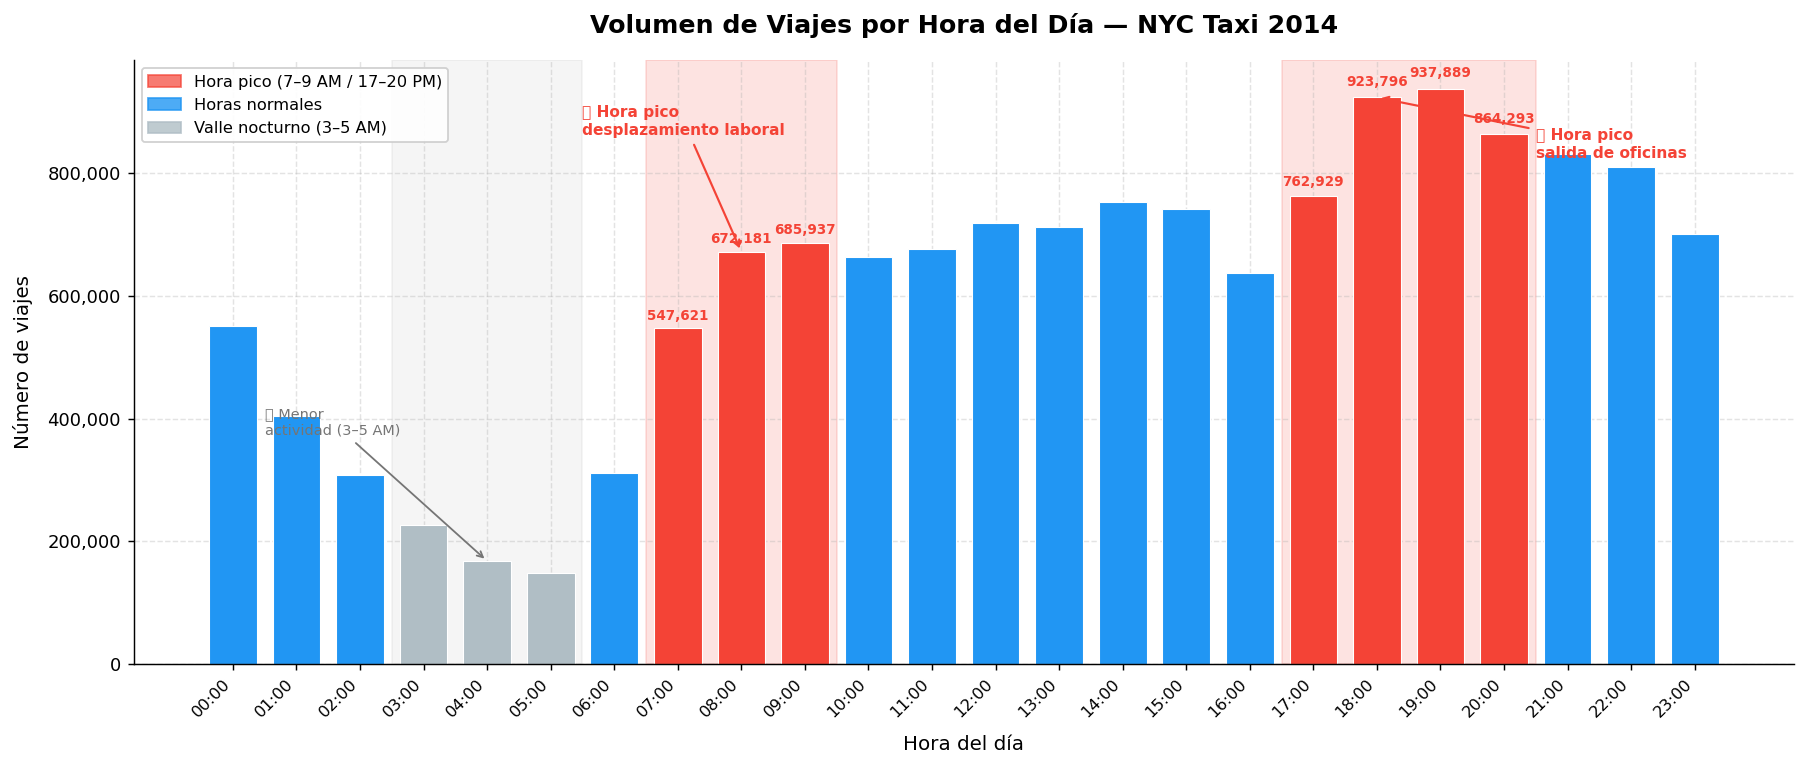

✅ Gráfico 1 exportado.


In [27]:
# ─────────────────────────────────────────────────────────────
# GRÁFICO 1 — VOLUMEN DE VIAJES POR HORA DEL DÍA
# Patrón bimodal: pico AM (7-9h) y pico PM (17-20h)
# ─────────────────────────────────────────────────────────────

# ── Ingeniería de características ────────────────────────────
# Extraemos la hora del día desde pickup_datetime
taxi_trips_clean['pickup_hour'] = taxi_trips_clean['pickup_datetime'].dt.hour

# Contamos viajes por hora (las 24 horas del día)
viajes_por_hora = (
    taxi_trips_clean
    .groupby('pickup_hour')
    .size()
    .reindex(range(24), fill_value=0)  # garantiza las 24 horas
    .reset_index()
)
viajes_por_hora.columns = ['hora', 'viajes']

# ── Configuración de la figura ────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# ── Zonas sombreadas ANTES de las barras (para que no las tape)
# Zona pico mañana: 7–9 AM
ax.axvspan(6.5, 9.5, alpha=0.15, color=COLOR_PICO, zorder=0)
# Zona pico tarde: 17–20 PM
ax.axvspan(16.5, 20.5, alpha=0.15, color=COLOR_PICO, zorder=0)
# Zona valle nocturno: 3–5 AM
ax.axvspan(2.5, 5.5, alpha=0.10, color='#9E9E9E', zorder=0)

# ── Colores de barras: rojo en pico, azul en el resto ─────────
colores = [
    COLOR_PICO if (7 <= h <= 9) or (17 <= h <= 20)
    else '#B0BEC5' if 3 <= h <= 5
    else COLOR_BASE
    for h in viajes_por_hora['hora']
]

# ── Barras verticales ─────────────────────────────────────────
bars = ax.bar(
    viajes_por_hora['hora'],
    viajes_por_hora['viajes'],
    color=colores,
    edgecolor='white',
    linewidth=0.6,
    width=0.75,
    zorder=2
)

# ── Etiquetas de valor en barras pico ─────────────────────────
for bar, h in zip(bars, viajes_por_hora['hora']):
    if (7 <= h <= 9) or (17 <= h <= 20):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.015,
            f"{bar.get_height():,.0f}",
            ha='center', va='bottom',
            fontsize=7.5, fontweight='bold', color=COLOR_PICO
        )

# ── Ejes y títulos ────────────────────────────────────────────
ax.set_xticks(range(24))
ax.set_xticklabels(
    [f'{h:02d}:00' for h in range(24)],
    rotation=45, ha='right', fontsize=9
)
ax.set_xlabel('Hora del día', fontsize=11, labelpad=8)
ax.set_ylabel('Número de viajes', fontsize=11, labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax.set_title(
    'Volumen de Viajes por Hora del Día — NYC Taxi 2014',
    fontsize=14, fontweight='bold', pad=15
)

# ── Anotaciones de contexto ───────────────────────────────────
ax.annotate(
    '🌅 Hora pico\ndesplazamiento laboral',
    xy=(8, viajes_por_hora.loc[viajes_por_hora.hora==8,'viajes'].values[0]),
    xytext=(5.5, viajes_por_hora['viajes'].max() * 0.92),
    fontsize=8.5, color=COLOR_PICO, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=COLOR_PICO, lw=1.2)
)
ax.annotate(
    '🌆 Hora pico\nsalida de oficinas',
    xy=(18, viajes_por_hora.loc[viajes_por_hora.hora==18,'viajes'].values[0]),
    xytext=(20.5, viajes_por_hora['viajes'].max() * 0.88),
    fontsize=8.5, color=COLOR_PICO, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=COLOR_PICO, lw=1.2)
)
ax.annotate(
    '🌙 Menor\nactividad (3–5 AM)',
    xy=(4, viajes_por_hora.loc[viajes_por_hora.hora==4,'viajes'].values[0] + 200),
    xytext=(0.5, viajes_por_hora['viajes'].max() * 0.40),
    fontsize=8, color='#757575',
    arrowprops=dict(arrowstyle='->', color='#757575', lw=1.0)
)

# ── Leyenda ───────────────────────────────────────────────────
leyenda = [
    mpatches.Patch(color=COLOR_PICO,  alpha=0.7, label='Hora pico (7–9 AM / 17–20 PM)'),
    mpatches.Patch(color=COLOR_BASE,  alpha=0.8, label='Horas normales'),
    mpatches.Patch(color='#B0BEC5',   alpha=0.8, label='Valle nocturno (3–5 AM)')
]
ax.legend(handles=leyenda, loc='upper left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('grafico1_viajes_por_hora.png', bbox_inches='tight')
plt.show()
print('✅ Gráfico 1 exportado.')

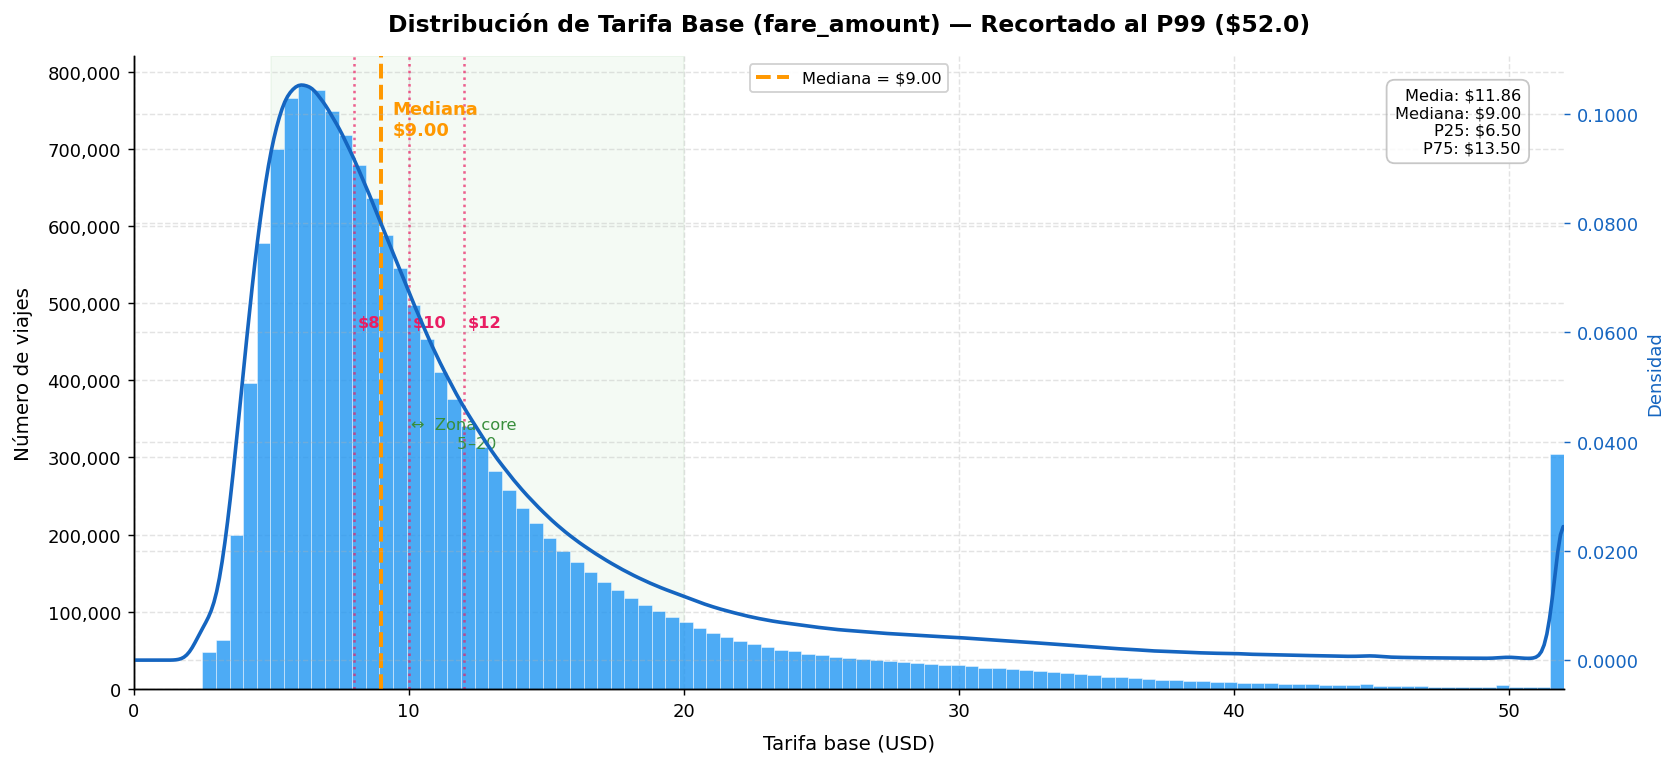

✅ Gráfico 2 exportado.


In [28]:
# ─────────────────────────────────────────────────────────────
# GRÁFICO 2 — DISTRIBUCIÓN DE TARIFA BASE (fare_amount)
# Recortado al percentil 99. Mediana, picos redondeados,
# mayoría entre $5–$20, cola larga por aeropuertos
# ─────────────────────────────────────────────────────────────

# ── Preparar datos ────────────────────────────────────────────
# Filtrar tarifas positivas y recortar al percentil 99
p99 = taxi_trips_clean['fare_amount'].quantile(0.99)
fare_data = taxi_trips_clean.loc[
    taxi_trips_clean['fare_amount'] > 0,
    'fare_amount'
].clip(upper=p99)

mediana_fare = fare_data.median()

# ── Figura ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

# ── Histograma con KDE ────────────────────────────────────────
n, bins, patches = ax.hist(
    fare_data,
    bins=100,
    color=COLOR_BASE,
    edgecolor='white',
    linewidth=0.3,
    alpha=0.80,
    density=False,
    zorder=2
)

# KDE superpuesta (eje secundario para escalar bien)
ax2 = ax.twinx()
fare_data.plot.kde(ax=ax2, color='#1565C0', linewidth=2.0, label='KDE')
ax2.set_ylabel('Densidad', fontsize=10, color='#1565C0')
ax2.tick_params(axis='y', colors='#1565C0')
ax2.spines['top'].set_visible(False)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

# ── Línea vertical de mediana ─────────────────────────────────
ax.axvline(
    mediana_fare, color=COLOR_MEDIANA,
    linestyle='--', linewidth=2.2, zorder=3,
    label=f'Mediana = ${mediana_fare:.2f}'
)
ax.text(
    mediana_fare + 0.4,
    n.max() * 0.92,
    f'Mediana\n${mediana_fare:.2f}',
    color=COLOR_MEDIANA, fontsize=10, fontweight='bold'
)

# ── Marcar picos redondeados ($8, $10, $12) ───────────────────
for precio, etiqueta in [(8,'$8'), (10,'$10'), (12,'$12')]:
    ax.axvline(precio, color='#E91E63', linestyle=':', linewidth=1.4, alpha=0.7)
    ax.text(precio + 0.15, n.max() * 0.60, etiqueta,
            color='#E91E63', fontsize=9, fontweight='bold')

# Zona core de tarifas ($5–$20)
ax.axvspan(5, 20, alpha=0.06, color='#4CAF50', zorder=0)
ax.text(12, n.max() * 0.40, '↔  Zona core\n     $5–$20',
        color='#388E3C', fontsize=9, ha='center')

# ── Etiquetas del eje X mejoradas ─────────────────────────────
ax.set_xlabel('Tarifa base (USD)', fontsize=11, labelpad=8)
ax.set_ylabel('Número de viajes', fontsize=11, labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(0, p99)

ax.set_title(
    f'Distribución de Tarifa Base (fare_amount) — Recortado al P99 (${p99:.1f})',
    fontsize=13, fontweight='bold', pad=14
)

# ── Estadísticas en el gráfico ────────────────────────────────
stats_txt = (
    f"Media: ${fare_data.mean():.2f}\n"
    f"Mediana: ${mediana_fare:.2f}\n"
    f"P25: ${fare_data.quantile(0.25):.2f}\n"
    f"P75: ${fare_data.quantile(0.75):.2f}"
)
ax.text(
    0.97, 0.95, stats_txt,
    transform=ax.transAxes, fontsize=9,
    va='top', ha='right',
    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.85, ec='#BDBDBD')
)

ax.legend(loc='upper center', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('grafico2_distribucion_tarifa.png', bbox_inches='tight')
plt.show()
print('✅ Gráfico 2 exportado.')

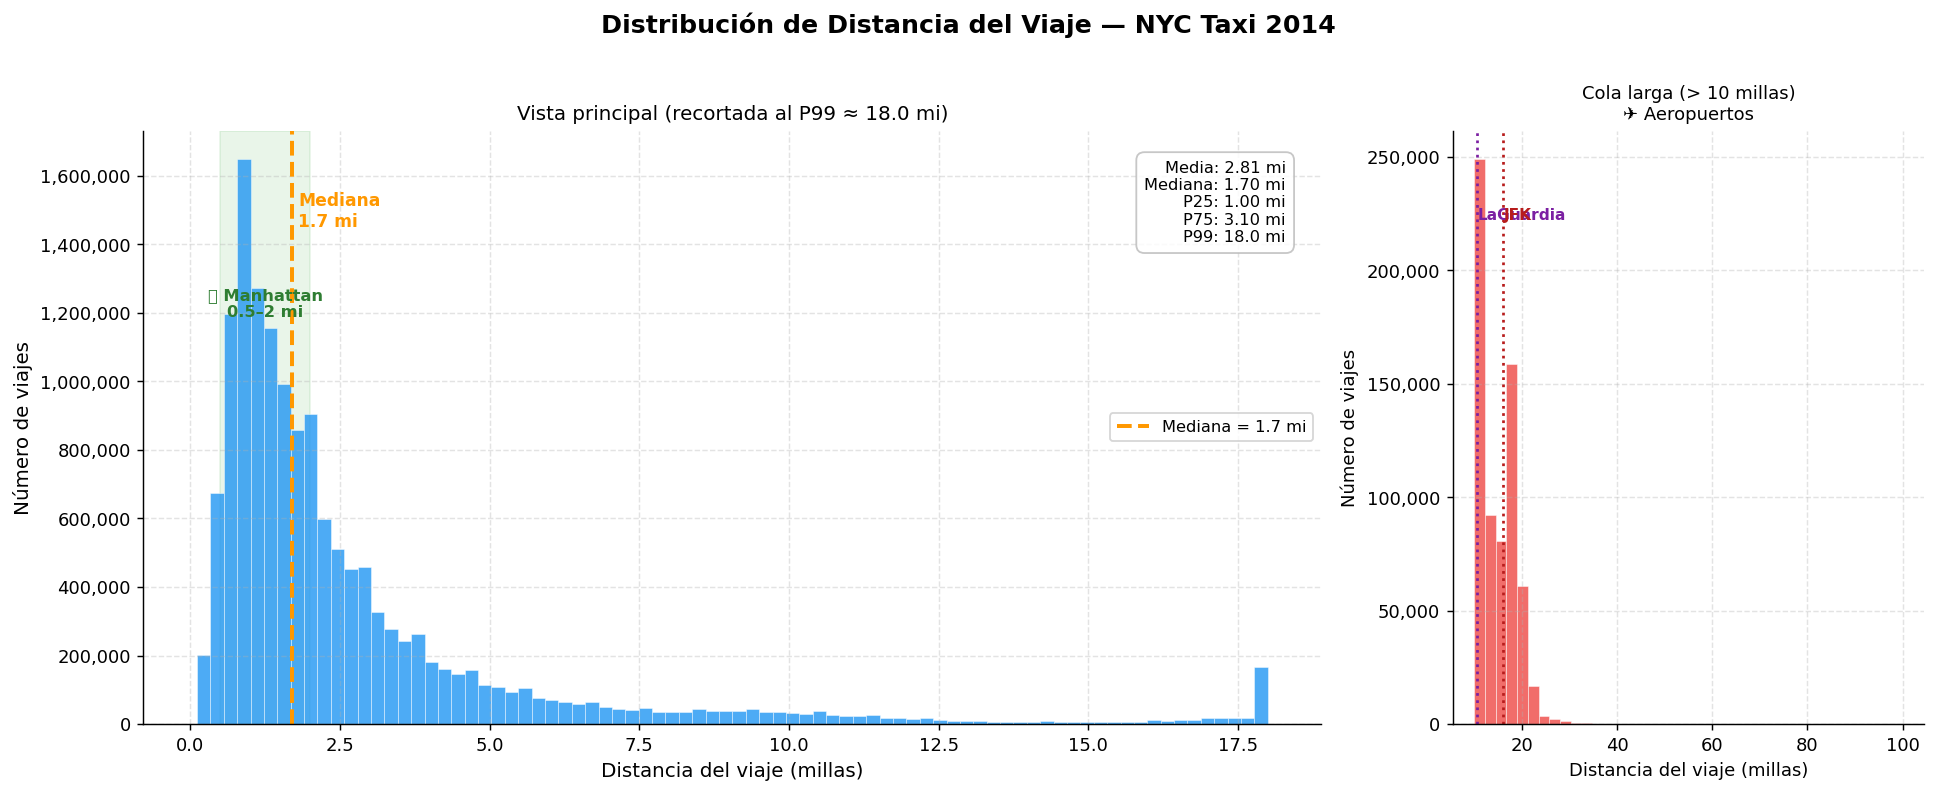

✅ Gráfico 3 exportado.


In [29]:
# ─────────────────────────────────────────────────────────────
# GRÁFICO 3 — DISTRIBUCIÓN DE DISTANCIA DEL VIAJE (trip_distance)
# Mediana ≈ 1.7 millas. Cola larga por aeropuertos (>15 mi)
# Pico principal 0.5–2 millas (Manhattan short trips)
# ─────────────────────────────────────────────────────────────

# ── Preparar datos ────────────────────────────────────────────
p99_dist = taxi_trips_clean['trip_distance'].quantile(0.99)

dist_data = taxi_trips_clean.loc[
    taxi_trips_clean['trip_distance'] > 0.1,
    'trip_distance'
]

# Dos vistas: recortada (principal) y completa (cola larga)
dist_recortada = dist_data.clip(upper=p99_dist)
mediana_dist = dist_data.median()

# ── Figura con dos paneles ────────────────────────────────────
fig, (ax_main, ax_cola) = plt.subplots(
    1, 2, figsize=(15, 6),
    gridspec_kw={'width_ratios': [2.5, 1]}
)
fig.suptitle(
    'Distribución de Distancia del Viaje — NYC Taxi 2014',
    fontsize=14, fontweight='bold', y=1.01
)

# ── Panel izquierdo: vista principal recortada al P99 ─────────
n_main, bins_main, patches_main = ax_main.hist(
    dist_recortada, bins=80,
    color=COLOR_BASE, edgecolor='white', linewidth=0.3, alpha=0.80
)

# Zona core Manhattan (0.5–2 millas)
ax_main.axvspan(0.5, 2.0, alpha=0.12, color='#4CAF50', zorder=0)
ax_main.text(
    1.25, n_main.max() * 0.72,
    '🗽 Manhattan\n0.5–2 mi',
    color='#2E7D32', fontsize=9, ha='center', fontweight='bold'
)

# Línea de mediana
ax_main.axvline(
    mediana_dist, color=COLOR_MEDIANA,
    linestyle='--', linewidth=2.2,
    label=f'Mediana = {mediana_dist:.1f} mi'
)
ax_main.text(
    mediana_dist + 0.1, n_main.max() * 0.88,
    f'Mediana\n{mediana_dist:.1f} mi',
    color=COLOR_MEDIANA, fontsize=9.5, fontweight='bold'
)

ax_main.set_xlabel('Distancia del viaje (millas)', fontsize=11)
ax_main.set_ylabel('Número de viajes', fontsize=11)
ax_main.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax_main.set_title(f'Vista principal (recortada al P99 ≈ {p99_dist:.1f} mi)', fontsize=11)
ax_main.legend(fontsize=9)

# ── Panel derecho: cola larga (viajes > 10 millas) ────────────
dist_cola = dist_data[dist_data > 10]
ax_cola.hist(
    dist_cola, bins=40,
    color='#EF5350', edgecolor='white', linewidth=0.3, alpha=0.85
)

# Marcadores de aeropuertos
jfk_dist  = 16.0  # distancia típica JFK
lga_dist  = 10.5  # distancia típica LaGuardia
for aeropuerto, dist_ae, color_ae in [
    ('LaGuardia', lga_dist, '#7B1FA2'),
    ('JFK',       jfk_dist, '#B71C1C')
]:
    ax_cola.axvline(dist_ae, linestyle=':', linewidth=1.5, color=color_ae)
    ax_cola.text(dist_ae + 0.2, ax_cola.get_ylim()[1] * 0.85 if ax_cola.get_ylim()[1] > 0 else 100,
                 aeropuerto, color=color_ae, fontsize=8.5, fontweight='bold')

ax_cola.set_xlabel('Distancia del viaje (millas)', fontsize=10)
ax_cola.set_ylabel('Número de viajes', fontsize=10)
ax_cola.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax_cola.set_title('Cola larga (> 10 millas)\n✈️ Aeropuertos', fontsize=10)

# Estadísticas
stats_txt = (
    f"Media: {dist_data.mean():.2f} mi\n"
    f"Mediana: {mediana_dist:.2f} mi\n"
    f"P25: {dist_data.quantile(0.25):.2f} mi\n"
    f"P75: {dist_data.quantile(0.75):.2f} mi\n"
    f"P99: {p99_dist:.1f} mi"
)
ax_main.text(
    0.97, 0.95, stats_txt,
    transform=ax_main.transAxes, fontsize=9,
    va='top', ha='right',
    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.85, ec='#BDBDBD')
)

plt.tight_layout()
plt.savefig('grafico3_distribucion_distancia.png', bbox_inches='tight')
plt.show()
print('✅ Gráfico 3 exportado.')

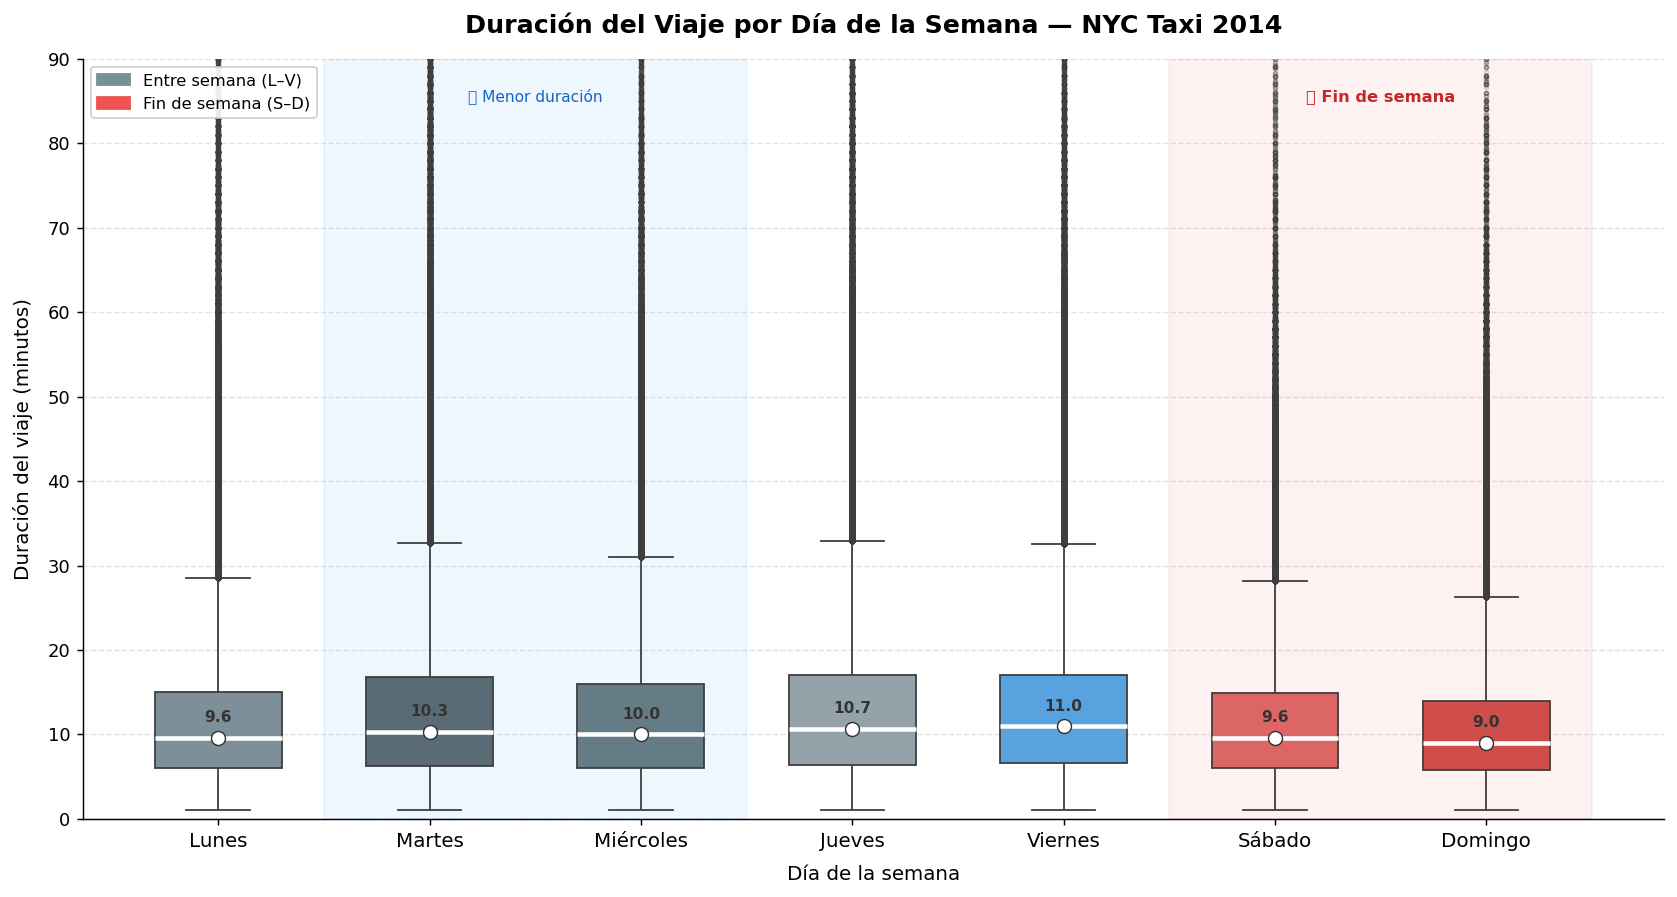

✅ Gráfico 4 exportado.


In [30]:
# ─────────────────────────────────────────────────────────────
# GRÁFICO 4 — DURACIÓN DEL VIAJE POR DÍA DE LA SEMANA
# Boxplot. Fines de semana ligeramente mayores.
# Martes y miércoles con menor duración.
# ─────────────────────────────────────────────────────────────

# ── Ingeniería de características ────────────────────────────
# Calcular duración del viaje en minutos
taxi_trips_clean['trip_duration_min'] = (
    (taxi_trips_clean['dropoff_datetime'] - taxi_trips_clean['pickup_datetime'])
    .dt.total_seconds() / 60
)

# Extraer día de la semana (0=Lunes … 6=Domingo)
taxi_trips_clean['day_of_week'] = taxi_trips_clean['pickup_datetime'].dt.dayofweek
taxi_trips_clean['day_name'] = taxi_trips_clean['pickup_datetime'].dt.day_name()

# Filtrar duraciones válidas (1–90 minutos)
df_dur = taxi_trips_clean[
    taxi_trips_clean['trip_duration_min'].between(1, 90)
].copy()

# Orden correcto de días
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
etiquetas_es = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

df_dur['day_name'] = pd.Categorical(
    df_dur['day_name'], categories=orden_dias, ordered=True
)
df_dur_sorted = df_dur.sort_values('day_name')

# ── Paleta: gris entre semana, color fines de semana ─────────
colores_dias = [
    '#78909C','#546E7A','#607D8B',   # L/M/X (más tranquilos)
    '#90A4AE',                         # J
    '#42A5F5',                         # V (viernes festivo)
    '#EF5350','#E53935'                 # S/D (fines de semana)
]

# ── Figura ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))

# Seaborn boxplot
sns.boxplot(
    data=df_dur_sorted,
    x='day_name',
    y='trip_duration_min',
    order=orden_dias,
    palette=colores_dias,
    width=0.6,
    flierprops=dict(marker='o', markersize=2, alpha=0.2, color='#90A4AE'),
    medianprops=dict(color='white', linewidth=2.5),
    ax=ax
)

# ── Superponer medianas como puntos ──────────────────────────
medianas = df_dur_sorted.groupby('day_name', observed=True)['trip_duration_min'].median()
for i, dia in enumerate(orden_dias):
    if dia in medianas.index:
        ax.scatter(i, medianas[dia], color='white', s=60, zorder=5, edgecolors='#333', linewidths=0.8)
        ax.text(i, medianas[dia] + 1.5, f'{medianas[dia]:.1f}',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#333')

# ── Zona sombreada fines de semana ────────────────────────────
ax.axvspan(4.5, 6.5, alpha=0.08, color='#EF5350', zorder=0)
ax.text(5.5, 85, '🎉 Fin de semana', ha='center', fontsize=9,
        color='#C62828', fontweight='bold')

# Zona Martes–Miércoles menor congestión
ax.axvspan(0.5, 2.5, alpha=0.07, color='#2196F3', zorder=0)
ax.text(1.5, 85, '📉 Menor duración', ha='center', fontsize=8.5,
        color='#1565C0')

# ── Ejes y formato ────────────────────────────────────────────
ax.set_xticklabels(etiquetas_es, fontsize=11)
ax.set_xlabel('Día de la semana', fontsize=11, labelpad=8)
ax.set_ylabel('Duración del viaje (minutos)', fontsize=11, labelpad=8)
ax.set_ylim(0, 90)
ax.set_title(
    'Duración del Viaje por Día de la Semana — NYC Taxi 2014',
    fontsize=14, fontweight='bold', pad=14
)

# Leyenda manual
parches = [
    mpatches.Patch(color='#78909C', label='Entre semana (L–V)'),
    mpatches.Patch(color='#EF5350', label='Fin de semana (S–D)'),
]
ax.legend(handles=parches, loc='upper left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('grafico4_duracion_por_dia.png', bbox_inches='tight')
plt.show()
print('✅ Gráfico 4 exportado.')

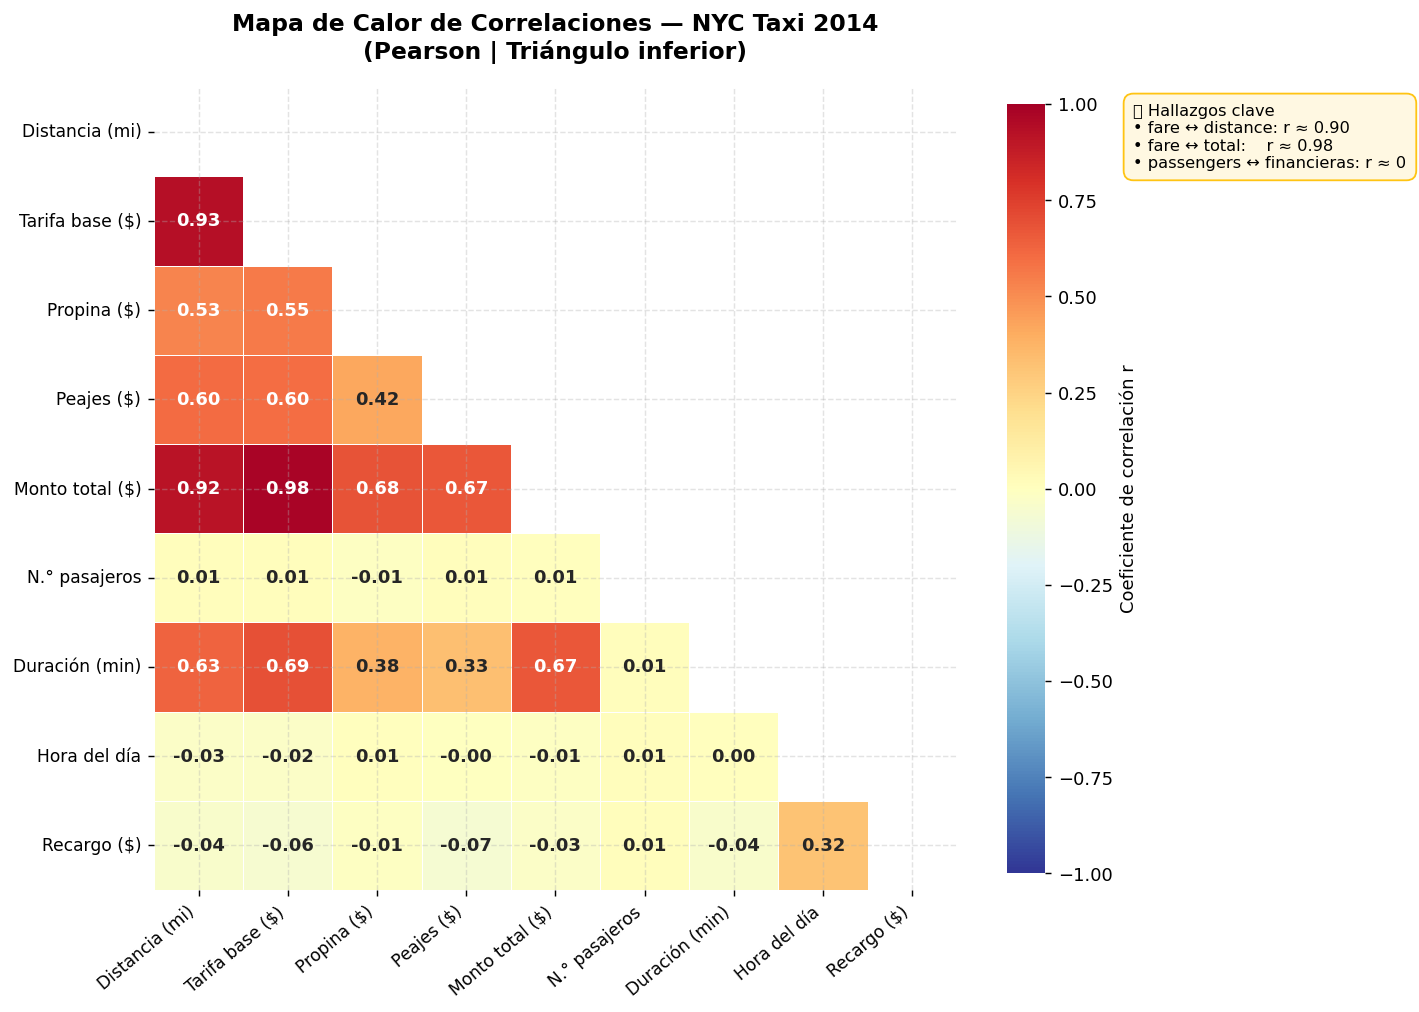

✅ Gráfico 5 exportado.


In [31]:
# ─────────────────────────────────────────────────────────────
# GRÁFICO 5 — MAPA DE CALOR DE CORRELACIONES (Pearson)
# 9 variables numéricas clave.
# fare_amount↔trip_distance r≈0.90 | fare↔total r≈0.98
# passenger_count ↔ financieras r≈0
# ─────────────────────────────────────────────────────────────

# ── Selección de variables numéricas ─────────────────────────
variables_corr = [
    'trip_distance',
    'fare_amount',
    'tip_amount',
    'tolls_amount',
    'total_amount',
    'passenger_count',
    'trip_duration_min',
    'pickup_hour',
    'surcharge'
]

# Aseguramos que existan todas las columnas (surcharge puede llamarse
# 'mta_tax' en algunas versiones del dataset)
vars_disponibles = [c for c in variables_corr if c in taxi_trips_clean.columns]

df_corr = taxi_trips_clean[vars_disponibles].copy()

# Calcular matriz de correlación de Pearson
corr_matrix = df_corr.corr(method='pearson')

# ── Figura ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))

# Máscara triángulo superior (evita redundancia)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Heatmap con seaborn
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 10, 'weight': 'bold'},
    cbar_kws={'label': 'Coeficiente de correlación r', 'shrink': 0.8},
    ax=ax
)

# ── Etiquetas personalizadas en español ───────────────────────
etiquetas_map = {
    'trip_distance':    'Distancia (mi)',
    'fare_amount':      'Tarifa base ($)',
    'tip_amount':       'Propina ($)',
    'tolls_amount':     'Peajes ($)',
    'total_amount':     'Monto total ($)',
    'passenger_count':  'N.° pasajeros',
    'trip_duration_min':'Duración (min)',
    'pickup_hour':      'Hora del día',
    'surcharge':        'Recargo ($)'
}

nuevas_etiquetas = [etiquetas_map.get(c, c) for c in vars_disponibles]
ax.set_xticklabels(nuevas_etiquetas, rotation=40, ha='right', fontsize=9.5)
ax.set_yticklabels(nuevas_etiquetas, rotation=0, fontsize=9.5)

# ── Anotaciones de hallazgos clave ────────────────────────────
ax.set_title(
    'Mapa de Calor de Correlaciones — NYC Taxi 2014\n'
    '(Pearson | Triángulo inferior)',
    fontsize=13, fontweight='bold', pad=16
)

# Cuadro de insights
insights = (
    "🔑 Hallazgos clave\n"
    "• fare ↔ distance: r ≈ 0.90\n"
    "• fare ↔ total:    r ≈ 0.98\n"
    "• passengers ↔ financieras: r ≈ 0"
)
ax.text(
    1.22, 0.98, insights,
    transform=ax.transAxes,
    fontsize=9, va='top', ha='left',
    bbox=dict(boxstyle='round,pad=0.6', fc='#FFF8E1', alpha=0.95, ec='#FFC107')
)

plt.tight_layout()
plt.savefig('grafico5_heatmap_correlaciones.png', bbox_inches='tight')
plt.show()
print('✅ Gráfico 5 exportado.')

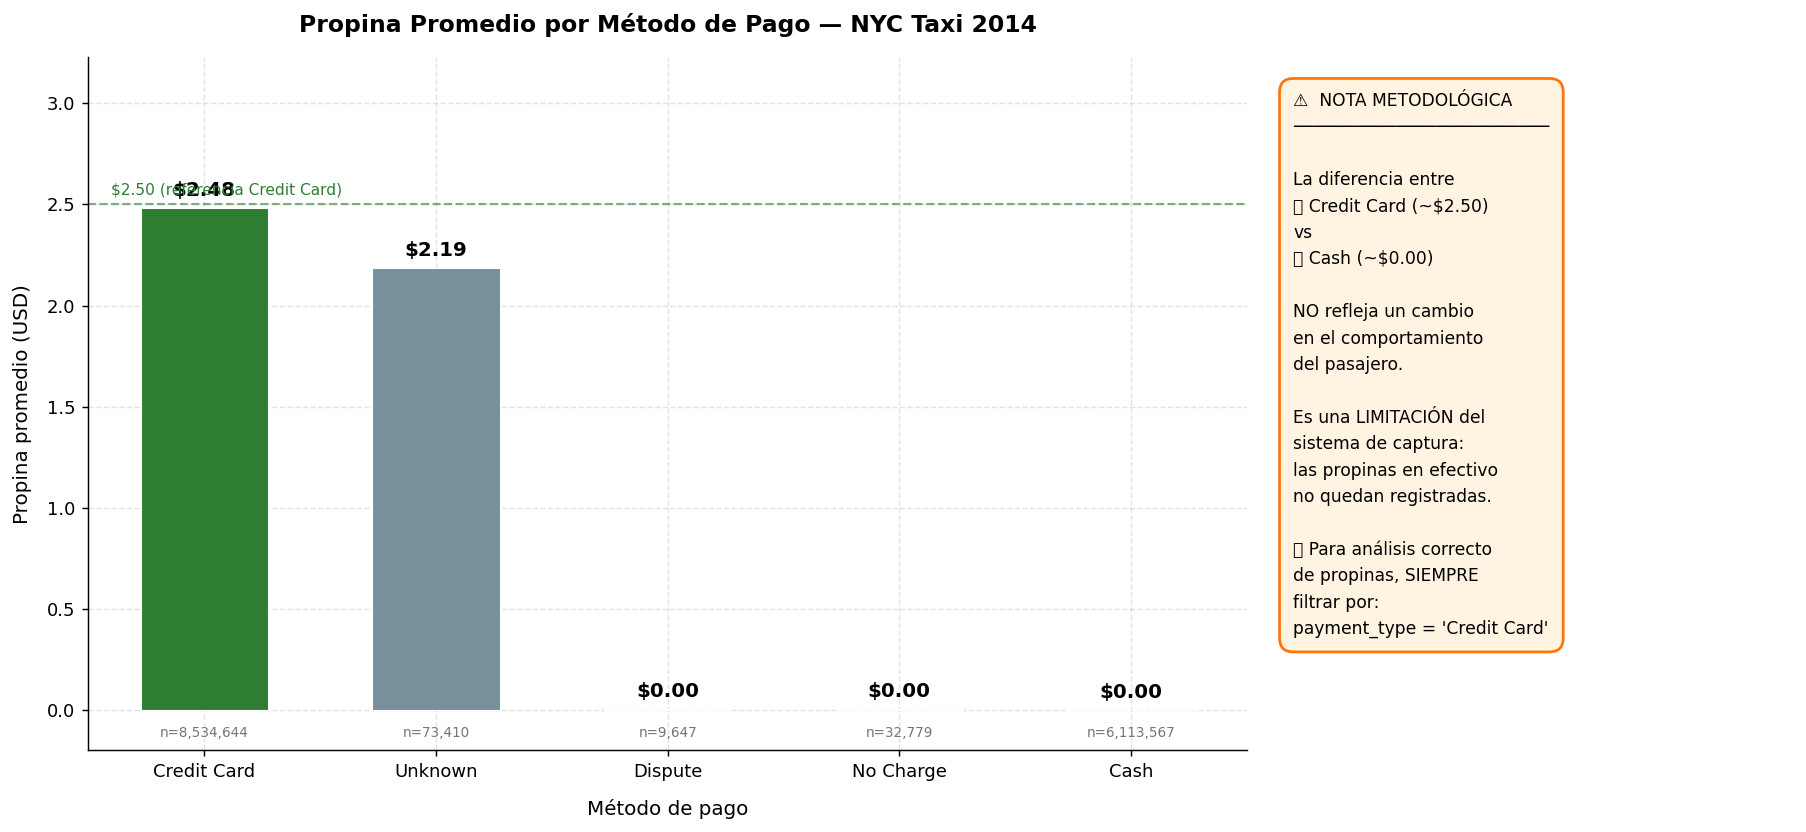

✅ Gráfico 6 exportado.


In [32]:
# ─────────────────────────────────────────────────────────────
# GRÁFICO 6 — PROPINAS POR MÉTODO DE PAGO (tip_amount)
# Diferencia radical: Credit Card ~$2.50 vs. Cash ~$0
# Nota metodológica: filtrar siempre por Credit Card para
# análisis de propinas.
# ─────────────────────────────────────────────────────────────

# ── Preparar datos ────────────────────────────────────────────
# La columna payment_type ya fue mapeada en el notebook original:
# 'Credit Card', 'Cash', 'Unknown', 'No Charge', 'Dispute'
propinas = (
    taxi_trips_clean
    .groupby('payment_type', observed=True)['tip_amount']
    .agg(promedio='mean', mediana='median', conteo='count')
    .reset_index()
    .sort_values('promedio', ascending=False)
)

# ── Paleta por tipo de pago ───────────────────────────────────
colores_pago = {
    'Credit Card': '#2E7D32',   # verde: registra propinas
    'Cash':        '#B71C1C',   # rojo: no captura propinas
    'Unknown':     '#78909C',
    'No Charge':   '#90A4AE',
    'Dispute':     '#B0BEC5'
}
colores_barras = [colores_pago.get(p, '#90A4AE') for p in propinas['payment_type'].astype(str)]

# ── Figura con panel principal y panel de advertencia ─────────
fig, (ax_bar, ax_info) = plt.subplots(
    1, 2, figsize=(14, 6.5),
    gridspec_kw={'width_ratios': [2.2, 1]}
)

# ── Barras comparativas ───────────────────────────────────────
bars = ax_bar.bar(
    propinas['payment_type'].astype(str),
    propinas['promedio'],
    color=colores_barras,
    edgecolor='white',
    linewidth=0.6,
    width=0.55,
    zorder=2
)

# Etiquetas encima de barras
for bar, row in zip(bars, propinas.itertuples()):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.04,
        f'${row.promedio:.2f}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )
    # Conteo de viajes debajo
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        -0.08,
        f'n={row.conteo:,.0f}',
        ha='center', va='top',
        fontsize=7.5, color='#757575'
    )

# Línea de referencia de $2.50
ax_bar.axhline(2.50, color='#2E7D32', linestyle='--', linewidth=1.2, alpha=0.6)
ax_bar.text(0.02, 2.55, '$2.50 (referencia Credit Card)',
            color='#2E7D32', fontsize=8.5, transform=ax_bar.get_yaxis_transform())

ax_bar.set_xlabel('Método de pago', fontsize=11, labelpad=10)
ax_bar.set_ylabel('Propina promedio (USD)', fontsize=11, labelpad=8)
ax_bar.set_title(
    'Propina Promedio por Método de Pago — NYC Taxi 2014',
    fontsize=13, fontweight='bold', pad=14
)
ax_bar.set_ylim(-0.2, propinas['promedio'].max() * 1.3)
ax_bar.spines['bottom'].set_visible(True)

# ── Panel derecho: nota metodológica ─────────────────────────
ax_info.axis('off')

nota = (
    "⚠️  NOTA METODOLÓGICA\n"
    "─────────────────────────\n\n"
    "La diferencia entre\n"
    "💳 Credit Card (~$2.50)\n"
    "vs\n"
    "💵 Cash (~$0.00)\n\n"
    "NO refleja un cambio\n"
    "en el comportamiento\n"
    "del pasajero.\n\n"
    "Es una LIMITACIÓN del\n"
    "sistema de captura:\n"
    "las propinas en efectivo\n"
    "no quedan registradas.\n\n"
    "✅ Para análisis correcto\n"
    "de propinas, SIEMPRE\n"
    "filtrar por:\n"
    "payment_type = 'Credit Card'"
)

ax_info.text(
    0.05, 0.95, nota,
    transform=ax_info.transAxes,
    fontsize=9.5, va='top', ha='left',
    linespacing=1.6,
    bbox=dict(
        boxstyle='round,pad=0.8',
        fc='#FFF3E0', alpha=0.97,
        ec='#FF6F00', linewidth=1.5
    )
)

plt.tight_layout()
plt.savefig('grafico6_propinas_por_pago.png', bbox_inches='tight')
plt.show()
print('✅ Gráfico 6 exportado.')